In [ ]:
# ============================================
# STEP 1: Import Libraries
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [ ]:
# ============================================
# STEP 2: Load Dataset
# ============================================

df = pd.read_csv("/content/output_candle_INFY.csv")

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

data = df[['Close']].copy()

/tmp/ipython-input-2354692327.py:7: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [ ]:
# ============================================
# STEP 3: Train-Test Split
# ============================================

train_size = int(len(data) * 0.8)

train = data[:train_size]
test = data[train_size:]

In [ ]:
# ============================================
# STEP 4: Normalize Data
# ============================================

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

In [ ]:
# ============================================
# STEP 5: Create Sequences
# ============================================

window_size = 4

def create_sequences(dataset, window_size):

    X = []
    y = []

    for i in range(window_size, len(dataset)):
        X.append(dataset[i-window_size:i])
        y.append(dataset[i])

    return np.array(X), np.array(y)


X_train, y_train = create_sequences(train_scaled, window_size)

In [ ]:
# ============================================
# STEP 6: Build RNN Model
# ============================================

model = Sequential()

model.add(SimpleRNN(64, input_shape=(window_size, 1)))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================
# STEP 7: Train Model
# ============================================

model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=8,
    verbose=1
)

Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0433
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0012
Epoch 3/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0011
Epoch 4/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0011
Epoch 5/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0012
Epoch 6/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.4490e-04
Epoch 7/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.9258e-04
Epoch 8/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8510e-04
Epoch 9/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9344e-04
Epoch 10/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.2539e-04
Epoch 11/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0011
Epoch 12/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.8244e-04
Epoch 13/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.0452e-04
Epoch 14/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.6553e-04
Epoch 15/100
78/78 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
# ============================================
# STEP 8: Walk-Forward Validation
# ============================================

history = list(train_scaled)

walk_predictions = []
walk_actual = []

for i in range(len(test_scaled)):

    input_seq = np.array(history[-window_size:])
    input_seq = input_seq.reshape(1, window_size, 1)

    pred = model.predict(input_seq, verbose=0)[0][0]

    walk_predictions.append(pred)
    walk_actual.append(test_scaled[i][0])

    history.append(test_scaled[i])


# Convert back to original scale

walk_predictions = scaler.inverse_transform(
    np.array(walk_predictions).reshape(-1,1)
)

walk_actual = scaler.inverse_transform(
    np.array(walk_actual).reshape(-1,1)
)

In [ ]:
# ============================================
# STEP 9: Evaluation Metrics
# ============================================

mae = mean_absolute_error(walk_actual, walk_predictions)

rmse = np.sqrt(mean_squared_error(walk_actual, walk_predictions))

mape = np.mean(np.abs((walk_actual - walk_predictions) / walk_actual)) * 100

accuracy = 100 - mape

print("\nRNN Model Performance:")
print("----------------------")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"Accuracy: {accuracy:.2f}%")


RNN Model Performance:
----------------------
MAE  : 40.9568
RMSE : 52.8356
MAPE : 2.75%
Accuracy: 97.25%


In [ ]:
# ============================================
# STEP 10: Next Week Forecast
# ============================================

last_sequence = data[['Close']].iloc[-window_size:].values

last_sequence_scaled = scaler.transform(last_sequence)

last_sequence_scaled = last_sequence_scaled.reshape(1, window_size, 1)

next_week_scaled = model.predict(last_sequence_scaled, verbose=0)

next_week_price = scaler.inverse_transform(next_week_scaled)[0][0]

current_price = data['Close'].iloc[-1]

next_week_return = (next_week_price - current_price) / current_price

print("\nNext Week Forecast (RNN):")
print("-------------------------")
print(f"Current Price        : {current_price:.2f}")
print(f"Predicted Price      : {next_week_price:.2f}")
print(f"Predicted Return (%) : {next_week_return*100:.2f}%")


Next Week Forecast (RNN):
-------------------------
Current Price        : 1535.80
Predicted Price      : 1547.97
Predicted Return (%) : 0.79%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


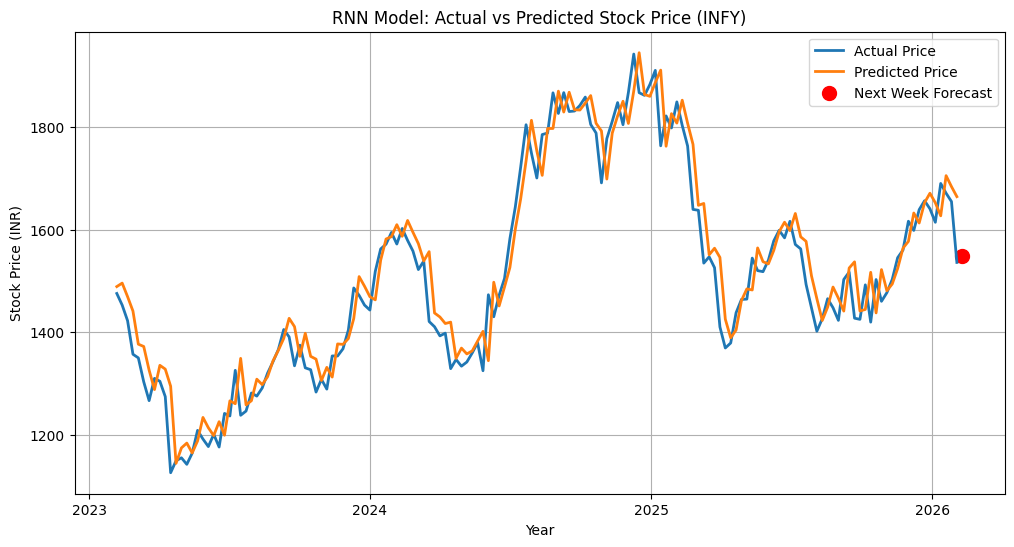

In [ ]:
# ============================================
# STEP 11: Plot Results
# ============================================

aligned_dates = data.index[train_size : train_size + len(walk_predictions)]

plt.figure(figsize=(12,6))

plt.plot(aligned_dates, walk_actual.flatten(),
         label="Actual Price", linewidth=2)

plt.plot(aligned_dates, walk_predictions.flatten(),
         label="Predicted Price", linewidth=2)

# Next week forecast point
next_date = data.index[-1] + pd.Timedelta(weeks=1)

plt.scatter(next_date,
            next_week_price,
            color='red',
            s=100,
            label="Next Week Forecast")

plt.title("RNN Model: Actual vs Predicted Stock Price (INFY)")
plt.xlabel("Year")
plt.ylabel("Stock Price (INR)")

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
print(data.tail(10))

             Close
Date              
2025-12-01  1616.2
2025-12-08  1598.2
2025-12-15  1638.7
2025-12-22  1656.1
2025-12-29  1640.4
2026-01-05  1614.1
2026-01-12  1689.8
2026-01-19  1670.8
2026-01-26  1654.5
2026-02-02  1535.8


CNN

Epoch 1/50


/tmp/ipython-input-169/3094093181.py:23: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_cnn['Date'] = pd.to_datetime(df_cnn['Date'])
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0370
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.0464e-04
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.2586e-04
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1270e-04
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9294e-04
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.7743e-04
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2378e-04
Epoch 8/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.3395e-04
Epoch 9/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.6330e-04
Epoch 10/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8718e-04
Epoch 11/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.1951e-04
Epoch 12/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.0735e-04
Epoch 13/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.4764e-04
Epoch 14/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.0862e-04
Epoch 15/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2m

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


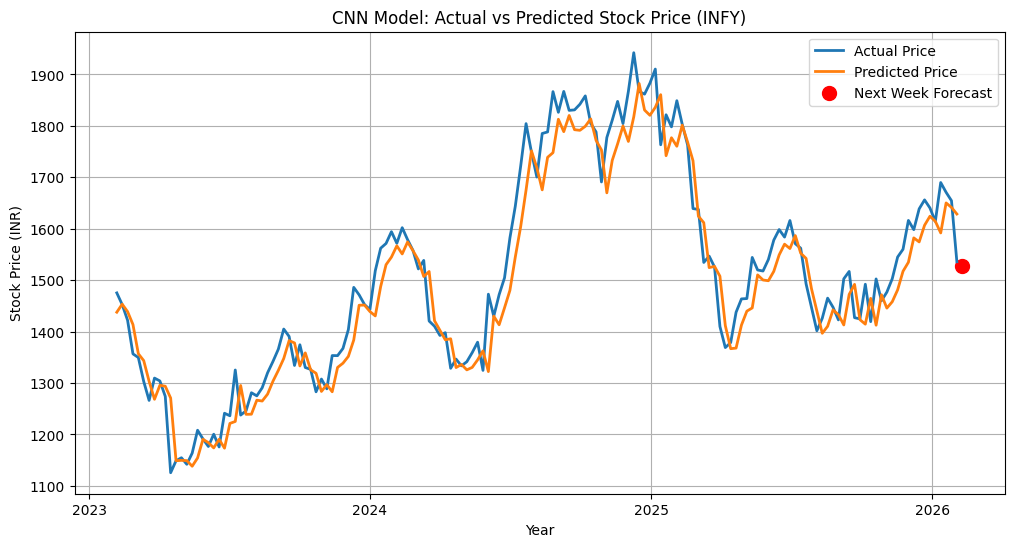

In [ ]:
# ============================================
# STEP 1: Import Libraries
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten


# ============================================
# STEP 2: Load Dataset
# ============================================

df_cnn = pd.read_csv("/content/output_candle_INFY.csv")

df_cnn['Date'] = pd.to_datetime(df_cnn['Date'])
df_cnn = df_cnn.sort_values('Date')
df_cnn.set_index('Date', inplace=True)

data = df_cnn[['Close']].copy()


# ============================================
# STEP 3: Train-Test Split
# ============================================

train_size = int(len(data) * 0.8)

train = data[:train_size]
test = data[train_size:]


# ============================================
# STEP 4: Normalize Data
# ============================================

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)


# ============================================
# STEP 5: Create Sequences
# ============================================

window_size = 4

def create_sequences(dataset, window_size):

    X = []
    y = []

    for i in range(window_size, len(dataset)):
        X.append(dataset[i-window_size:i])
        y.append(dataset[i])

    return np.array(X), np.array(y)


X_train, y_train = create_sequences(train_scaled, window_size)


# ============================================
# STEP 6: Build CNN Model
# ============================================

model = Sequential()

model.add(Conv1D(
    filters=64,
    kernel_size=2,
    activation='relu',
    input_shape=(window_size, 1)
))

model.add(Flatten())

model.add(Dense(100, activation='relu'))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)


# ============================================
# STEP 7: Train Model
# ============================================

model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    verbose=1
)


# ============================================
# STEP 8: Walk-Forward Validation
# ============================================

history = list(train_scaled)

walk_predictions = []
walk_actual = []

for i in range(len(test_scaled)):

    input_seq = np.array(history[-window_size:])
    input_seq = input_seq.reshape(1, window_size, 1)

    pred = model.predict(input_seq, verbose=0)[0][0]

    walk_predictions.append(pred)
    walk_actual.append(test_scaled[i][0])

    history.append(test_scaled[i])


# Convert back to original scale

walk_predictions = scaler.inverse_transform(
    np.array(walk_predictions).reshape(-1,1)
)

walk_actual = scaler.inverse_transform(
    np.array(walk_actual).reshape(-1,1)
)


# ============================================
# STEP 9: Evaluation Metrics
# ============================================

mae = mean_absolute_error(walk_actual, walk_predictions)

rmse = np.sqrt(mean_squared_error(walk_actual, walk_predictions))

mape = np.mean(np.abs((walk_actual - walk_predictions) / walk_actual)) * 100

accuracy = 100 - mape

print("\nCNN Model Performance:")
print("----------------------")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"Accuracy: {accuracy:.2f}%")


# ============================================
# STEP 10: Next Week Forecast
# ============================================

last_sequence = df_cnn[['Close']].iloc[-window_size:].values

last_sequence_scaled = scaler.transform(last_sequence)

last_sequence_scaled = last_sequence_scaled.reshape(1, window_size, 1)

next_week_scaled = model.predict(last_sequence_scaled, verbose=0)

next_week_price = scaler.inverse_transform(next_week_scaled)[0][0]

current_price = df_cnn['Close'].iloc[-1]

next_week_return = (next_week_price - current_price) / current_price

print("\nNext Week Forecast (CNN):")
print("-------------------------")
print(f"Current Price        : {current_price:.2f}")
print(f"Predicted Price      : {next_week_price:.2f}")
print(f"Predicted Return (%) : {next_week_return*100:.2f}%")


# ============================================
# STEP 11: Plot Results
# ============================================

aligned_dates = df_cnn.index[train_size : train_size + len(walk_predictions)]

plt.figure(figsize=(12,6))

plt.plot(aligned_dates,
         walk_actual.flatten(),
         label="Actual Price",
         linewidth=2)

plt.plot(aligned_dates,
         walk_predictions.flatten(),
         label="Predicted Price",
         linewidth=2)

# Next week forecast point
next_date = df_cnn.index[-1] + pd.Timedelta(weeks=1)

plt.scatter(next_date,
            next_week_price,
            color='red',
            s=100,
            label="Next Week Forecast")

plt.title("CNN Model: Actual vs Predicted Stock Price (INFY)")
plt.xlabel("Year")
plt.ylabel("Stock Price (INR)")

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.legend()
plt.grid(True)

plt.show()